In [29]:
import math
import os
from dog import LDoG
from dog import PolynomialDecayAverager
from untils.data_split import DataSplit
import numpy as np
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"
import torch
import torchvision.transforms
from torch.utils.data import DataLoader
import statistics
from data_loaders.segmentation_dataset import SegmentationDataset
from models.big_unet import UNet
from untils.loss import MixedLoss
from untils.test import evaluate, metric
from untils.train import EarlyStopping, train_one_epoch
import math
import sys

In [30]:
sunny_summer=[ 'nf4123_016.png',
 'nf4123_017.png',
'nf4123_018.png',
'nf4123_019.png',
'nf4123_020.png',
'nf4123_021.png',
'nf4123_022.png',
 'nf4123_023.png',
 'nf4123_024.png',
 'nf4123_025','nf4321_154.png','nf4321_155.png',
'nf4321_156.png',
'nf4321_157.png',
'nf4321_158.png']

In [31]:
EPOCHS = 100#15#70#15#19
TRAIN_MODEL = True
EVALUATE = True
#N_CLASS = 11
N_CLASS = 11
N_BANDS = 25

ds = DataSplit()
test, val, train = ds.get_files("./assets")

data_path = "/dsi/scratch/home/dsi/yanivz_datasets/HSI_Drive_v2_01/Image_dataset/cubes_fl32"

labels_path = "/dsi/scratch/home/dsi/yanivz_datasets/HSI_Drive_v2_01/Image_dataset/labels"

train_dataset = SegmentationDataset(
    image_dir=data_path,
    n_class=N_CLASS,
    mask_dir=labels_path,
    mode="Hyper",
    data_key="cube",
    samples_names=train,
    transform=None,
)
train_dataset
#train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)


In [32]:
#'nf4321_154.png'


In [33]:
arr= np.array(train_dataset[0]["image"])[7,:,:]

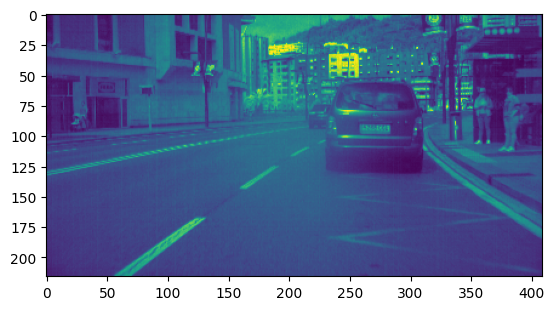

In [34]:
import matplotlib.pyplot as plt 
plt.imshow(arr)

In [35]:
import numpy as np
import os
from collections import Counter
from torch.utils.data import Dataset, DataLoader

class TiledSegmentationDataset(Dataset):
    def __init__(self, original_dataset, tile_size=16,tran=None):
        self.original_dataset = original_dataset
        self.tile_size = tile_size
        self.tran = tran
        self.tiles = self._extract_tiles()
    def _extract_tiles(self):
        tiles = []
        for data in self.original_dataset:
            #print(image,label)
            image=data["image"] if self.tran == None else self.tran(data["image"])
            label=data["mask"]
            c, h, w = image.shape  # Adjusted to handle channel first
            for i in range(0, h, self.tile_size):
                for j in range(0, w, self.tile_size):
                    tile_image = image[:, i:i+self.tile_size, j:j+self.tile_size]  # Slicing height and width
                    tile_label = label[i:i+self.tile_size, j:j+self.tile_size]
                    if tile_image.shape[1] == self.tile_size and tile_image.shape[2] == self.tile_size:
                        tiles.append((tile_image, tile_label))
        return tiles

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        return self.tiles[idx]

def get_most_popular_label(tile_label, threshold=0.6):
    flat_labels = tile_label.flatten()
    label_counts = Counter(flat_labels)
    most_common_label, count = label_counts.most_common(1)[0]
    if count / len(flat_labels) > threshold:
        return most_common_label
    else:
        return 'undefined'

# Example usage:
image_paths = ['path/to/image1.npy', 'path/to/image2.npy', ...]
label_paths = ['path/to/label1.npy', 'path/to/label2.npy', ...]
print("here")
#original_dataset = OriginalSegmentationDataset(image_paths, label_paths)
tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16)
print("out of")
len(tiled_dataset)
# # Directories to save the tiles
# output_dir = 'path/to/save/tiles'
# os.makedirs(output_dir, exist_ok=True)

# for idx, (tile_image, tile_label) in enumerate(tiled_dataset):
#     most_popular_label = get_most_popular_label(tile_label)
#     label_dir = os.path.join(output_dir, str(most_popular_label))
#     os.makedirs(label_dir, exist_ok=True)
    
#     np.save(os.path.join(label_dir, f'tile_image_{idx}.npy'), tile_image)
#     np.save(os.path.join(label_dir, f'tile_label_{idx}.npy'), tile_label)


here
out of


171275

In [36]:
# class TiledSegmentationDataset(Dataset):
#     def __init__(self, original_dataset, tile_size=32):
#         self.original_dataset = original_dataset
#         self.tile_size = tile_size
#         self.tiles = self._extract_tiles()

#     def _extract_tiles(self):
#         tiles = []
#         for data in self.original_dataset:
#             image=data["image"]
#             label=data["mask"]
#             c, h, w = image.shape  # Adjusted to handle channel first
#             for i in range(0, h, self.tile_size):
#                 for j in range(0, w, self.tile_size):
#                     tile_image = image[:, i:i+self.tile_size, j:j+self.tile_size]  # Slicing height and width
#                     tile_label = label[i:i+self.tile_size, j:j+self.tile_size]
#                     if tile_image.shape[1] == self.tile_size and tile_image.shape[2] == self.tile_size:
#                         tiles.append((tile_image, tile_label))
#         return tiles

#     def __len__(self):
#         return len(self.tiles)

#     def __getitem__(self, idx):
#         return self.tiles[idx]

# tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=4)


In [37]:
print("jojoojo")

jojoojo


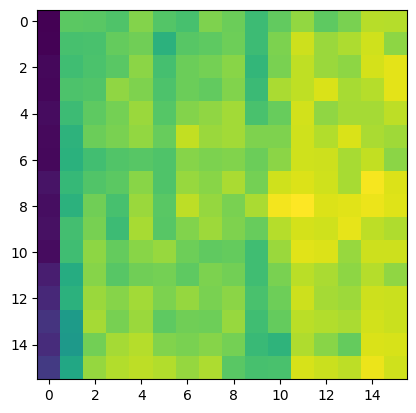

In [38]:
plt.imshow(tiled_dataset[5][0][7,:,:])
#tiled_dataset[3][0][:].shape

In [39]:
len(tiled_dataset)

171275

In [40]:
#images = [image1, image2, image3, image4, image5]

#plt.figure(figsize=(15, 5))

for i in range(2000,2010):
    img = tiled_dataset[i][0][7,:,:]
    plt.subplot(2001, 2011,1+ i )
    plt.imshow(img)
    plt.axis('off')

plt.show()


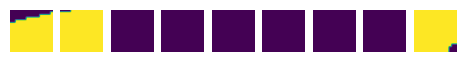

In [41]:
for i in range(201,210):
    img = tiled_dataset[i][1][:,:]
    plt.subplot(1, 10,1+ i -201)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [42]:
tiled_dataset[209][1][:,:]


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]])

In [43]:
def get_most_popular_label(tile_label, threshold=0.8):
    flat_labels = np.array(tile_label).flatten()
    label_counts = Counter(flat_labels)
    #print(label_counts)
    most_common_label, count = label_counts.most_common(1)[0]
    #if most_common_label==0:
        #print(label_counts.most_common(2))
    #    return label_counts.most_common(2)[-1][0]
    #print(count,len(flat_labels),count / len(flat_labels))
    if count / len(flat_labels) > threshold:
        return most_common_label
    else:
        return 'undefined'
myl=Counter()
for i in range(0,len(tiled_dataset)-2):
    lb = tiled_dataset[i][1][:,:]
    myl[get_most_popular_label(lb)]+=1
myl

Counter({'undefined': 48707,
         6: 3292,
         0: 37221,
         5: 5333,
         4: 948,
         1: 56825,
         3: 18110,
         7: 165,
         9: 58,
         2: 489,
         10: 117,
         8: 8})

In [44]:
myl[10]

117

In [45]:
import numpy as np
labels=range(1,11)
# Assuming `labels` is a list or numpy array of class labels
class_sample_count = np.array([myl[t] for t in np.unique(labels)])
weight = 1. / class_sample_count
samples_weight =[weight[t-1] for t in labels]
samples_weight =  np.array([t if t**2!=float('inf') else 0 for t in samples_weight])
samples_weight = torch.from_numpy(samples_weight)
samples_weight = samples_weight.double()
samples_weight

tensor([1.7598e-05, 2.0450e-03, 5.5218e-05, 1.0549e-03, 1.8751e-04, 3.0377e-04,
        6.0606e-03, 1.2500e-01, 1.7241e-02, 8.5470e-03], dtype=torch.float64)

In [46]:
class FilteredTileDataset(Dataset):
    def __init__(self, tile_dataset,bad_labels=[0,'undefined']):
        self.filtered_tiles = [
            tile for i,tile in enumerate(tile_dataset)
            if (get_most_popular_label(tile[1][:,:])!=bad_labels[0] and get_most_popular_label(tile[1][:,:])!=bad_labels[1])
        ]

    def __len__(self):
        return len(self.filtered_tiles)

    def __getitem__(self, idx):
        return self.filtered_tiles[idx]
fl=FilteredTileDataset(tiled_dataset)
len(fl)

85345

In [47]:
sum(list(myl.values()))#-23011 54099 

171273

In [48]:
fl=FilteredTileDataset(tiled_dataset)
len(fl)

85345

In [49]:
len(fl)+myl[0]+myl['undefined']

171273

In [50]:
from torch import nn



class Embedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv3d(1,3,(3,3,3))
        self.max1=nn.MaxPool3d(3, stride=2,padding=0)
        self.conv2=nn.Conv3d(3,6,(2,2,2))
        self.max2=nn.MaxPool3d(3, stride=2,padding=0)
        self.projection_head = nn.Linear(96 , 64)

    def forward(self, x):
        #x = self.backbone(x).flatten(start_dim=1)
        x= self.max2(self.conv2(self.max1(self.conv1(x))))
        print(x.shape)
        x = x.flatten(dim=1)
        z = self.projection_head(x)
        return z
#net=Embedder()
#net(tiled_dataset[0][0]).shape
#tiled_dataset[0][0].shape
#net(torch.zeros((6,25,16,16)).shape)

In [51]:
import torch
import torch.nn as nn

class Embedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv3d(1, 3, (3, 3, 3))
        self.max1 = nn.MaxPool3d(3, stride=2, padding=0)
        self.conv2 = nn.Conv3d(3, 6, (2, 2, 2))
        self.max2 = nn.MaxPool3d(3, stride=2, padding=0)
        
        self.projection_head = nn.Linear(96, 64)  # Adjusted input dimension

    def forward(self, x):
        #print("x0",x.shape)
        #if len(x.shape)==3:
        #    x=x.unsqueeze(0)
        x = self.max1(self.conv1(x))
        #print("x1",x.shape)
        x = self.conv2(x)
        x = self.max2(x)
        #print("x2",x.shape)
        #x = x.view(x.size(0), -1)  # Flatten starting from the batch dimension
        #print(x.shape)
        #print("x3",x.shape)
        z = self.projection_head(x.view(x.size(0), -1))
        return z

# Example usage
embedder = Embedder()
input_tensor = torch.randn(64,1,25, 16, 16)  # Batch size 64, 1 channel, depth 25, height 16, width 16
output = embedder(input_tensor)
print(output.shape)  # Should print torch.Size([64, 64])

torch.Size([64, 64])


In [52]:
plop=torch.randn(1,64,25, 16, 16)
fresh=plop.squeeze().unsqueeze(0)
sum(sum(sum(fresh.squeeze()[8]==plop.squeeze()[8]))),plop.squeeze()[8].size()

(tensor(6400), torch.Size([25, 16, 16]))

In [53]:
import torch
batch_size=8
# Assuming tensor is your input tensor
tensor = torch.randn(batch_size, 6, 4, 2, 2)

# Flatten each sample in the batch
flattened_tensor = tensor.view(tensor.size(0), -1)

# Check the shape of the flattened tensor
print(flattened_tensor.shape)
tensor[5].flatten()==flattened_tensor[5]

torch.Size([8, 96])


tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True])

In [54]:
class ToNumpy:
    def __call__(self, sample):
        if isinstance(sample, torch.Tensor):
            return sample.numpy()
        elif isinstance(sample, (tuple, list)):
            return [s.numpy() if isinstance(s, torch.Tensor) else s for s in sample]
        else:
            raise TypeError(f"Expected input sample to be torch.Tensor or a tuple/list of torch.Tensors, got {type(sample)}")

# Example usage of the custom transform
to_numpy_transform = ToNumpy()


In [55]:
# ignored_labels=[0,'undefined']
# tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)# datasets.CNIFAR10(root='./data', train=True, download=True, transform=transform)
# #train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# # Filter out the indices with the ignored labels
# bad_dix= [i for i, label in enumerate(tiled_dataset.targets) if label in ignored_labels]
# print("bad_dix",len(bad_dix))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import copy
class TwoCropTransform:
    """Create two crops of the same image"""
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return [self.transform(x), self.transform(x)]
# transform1 = transforms.Compose([
#     #ToNumpy(),
#     transforms.RandomResizedCrop(16),
#     transforms.RandomHorizontalFlip(),
#     #transforms.ToTensor(),
# ])
shift_limit=0.1
zoom_limit=1.2
my_shear=0.01
two_crops=TwoCropTransform(transforms.Compose([
    #ToNumpy(),
    transforms.RandomResizedCrop(16),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(shift_limit, shift_limit),
        scale=(1.0, zoom_limit)
    ),
    transforms.RandomAffine(
        degrees=0,
        shear=my_shear * 180 / 3.14159  # convert radians to degrees
    )
    #transforms.ToTensor(),
]))
class Predictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Predictor, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

# BYOL training step
# def byol_training_step(online_net, target_net, predictor, data, optimizer, tau=0.99):
#     img1, img2 = data
#     print(img1.shape)#, img2.shape)# =img1, img2
#     # Forward pass through online and target networks
#     z1_online = predictor(online_net(img1))
#     z2_online = predictor(online_net(img2))
#     with torch.no_grad():
#         z1_target = target_net(img1)
#         z2_target = target_net(img2)
    
#     # Loss calculation
#     loss = nn.MSELoss()(z1_online, z2_target) + nn.MSELoss()(z2_online, z1_target)
    
#     # Backpropagation
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
    
#     # EMA update for target network
#     for online_param, target_param in zip(online_net.parameters(), target_net.parameters()):
#         target_param.data = tau * target_param.data + (1 - tau) * online_param.data
    
#     return loss.item()

# Main training loop
# BYOL training step
def byol_training_step(online_net, target_net, predictor, img1, img2, optimizer, tau=0.99):
    # Forward pass through online and target networks
    z1_online = predictor(online_net(img1))
    z2_online = predictor(online_net(img2))
    with torch.no_grad():
        z1_target = target_net(img1)
        z2_target = target_net(img2)
    
    # Loss calculation
    loss = nn.MSELoss()(z1_online, z2_target) + nn.MSELoss()(z2_online, z1_target)
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # EMA update for target network
    for online_param, target_param in zip(online_net.parameters(), target_net.parameters()):
        target_param.data = tau * target_param.data + (1 - tau) * online_param.data
    
    return loss.item()

# Main training loop
def train_byol(online_net, target_net, predictor, train_loader, epochs, device, lr=0.0001):# lr=0.001
    optimizer = optim.Adam(list(online_net.parameters()) + list(predictor.parameters()), lr=lr)
    for epoch in range(epochs):
        print(f'Start epc {epoch}')
        epc_loss=0
        n_batch=0
        online_net.train()
        predictor.train()
        for batch in train_loader:
            img1,img2 = two_crops(batch[0])#, batch[0][1].to(device)
            #print(img1.shape,img2.shape)
            img1,img2 =img1.squeeze().unsqueeze(1),img2.squeeze().unsqueeze(1)
            #print(img1.shape,img2.shape)

            loss = byol_training_step(online_net, target_net, predictor,img1.to(device),img2.to(device), optimizer)#pay ettention- will create probelms for different size
            #print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')
            epc_loss+=loss
            n_batch+=1
        print(f'Total Epoch [{epoch+1}/{epochs}], Loss: {epc_loss/n_batch:.6f}')
  


# Data augmentation and loading
print("1234")
ignored_labels=[0,'undefined']
tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)# datasets.CNIFAR10(root='./data', train=True, download=True, transform=transform)
fl_tiled_dataset=FilteredTileDataset(tiled_dataset)
#train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))
train_loader = torch.utils.data.DataLoader(fl_tiled_dataset, batch_size=64, shuffle=True,sampler=sampler)

# Initialize networks
online_net = Embedder().to("cuda")
target_net = copy.deepcopy(online_net).to("cuda")
predictor = Predictor(64, 128, 64).to("cuda")

# Train BYOL
train_byol(online_net, target_net, predictor, train_loader, epochs=25,device="cuda")


1234


KNN

In [45]:
import numpy as np
from collections import Counter
my_embeddings = []
my_labels = []
to_knn_loader=train_loader#fl_tiled_dataset#FilteredTileDataset(tiled_dataset)
for batch in to_knn_loader:
    #print(batch[0].shape)
    if batch[0].shape[0]!=64:
        break
    img=batch[0].to("cuda")
    labels =batch[1] #, batch[0][1].to(device)
    #print(img.shape,labels.shape)
    
    common_label = get_most_popular_label(labels)
    embedding = target_net(img.squeeze().unsqueeze(1))
    print(embedding.shape)
    my_embeddings.append(np.array(embedding.detach().cpu().numpy()))
    my_labels.append(common_label)
# Convert to numpy arrays
embeddings = np.array(my_embeddings)
print("embeddings.shape=",embeddings.shape)
labels = np.array(my_labels)


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42)

# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Print classification report
print(classification_report(y_test, y_pred))


torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
embeddings.shape= (36, 64, 64)


ValueError: Found input variables with inconsistent numbers of samples: [2304, 36]

In [ ]:
gpt

In [ ]:
import numpy as np
from collections import Counter

# Assuming embedder is a function that takes a 16x16 image tile and returns a 64-dimensional embedding
def embedder(tile):
    # Dummy function for illustration
    return np.random.rand(64)+np.max(tile)

# Example tile and label map
tiles = np.random.rand(100, 16, 16, 3)
tiles[50:] = 1+tiles[50:] # 100 image tiles of size 16x16 with 3 channels
labels_map = np.random.randint(0, 10, (100, 16, 16))  # 100 label maps of size 16x16 with labels between 0 and 9

# Function to find the most common label in a label map
def most_common_label(label_map):
    label_counts = Counter(label_map.flatten())
    return label_counts.most_common(1)[0][0]

# Initialize lists to hold embeddings and labels
embeddings = []
labels = []

# Loop through each tile and label map
for tile, label_map in zip(tiles, labels_map):
    embedding = embedder(tile)
    common_label = most_common_label(label_map)
    embeddings.append(embedding)
    labels.append(common_label)

# Convert to numpy arrays
embeddings = np.array(embeddings)
labels = np.array(labels)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42)

# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Print classification report
print(classification_report(y_test, y_pred))


In [ ]:
# #tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)# datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# class TwoCropTransform:
#     """Create two crops of the same image"""
#     def __init__(self, transform):
#         self.transform = transform

#     def __call__(self, x):
#         return [self.transform(x), self.transform(x)]

# tiled_dataset2 = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)#
# train_loader2 = torch.utils.data.DataLoader(tiled_dataset2, batch_size=64, shuffle=True)


In [ ]:
# for batch in train_loader2:
#     print(len(batch))#.shape)
#     print(batch[0].shape)
#     print(batch[1].shape)
#     img1, img2 = batch[0][0], batch[0][1]
#     print(img1.shape,img2.shape)
#     break


In [ ]:
print("done")

In [ ]:
#0.6 threshold
Total Epoch [1/10], Loss: 0.015145
Start epc 1
Total Epoch [2/10], Loss: 0.015122
Start epc 2
Total Epoch [3/10], Loss: 0.013334
Start epc 3
Total Epoch [4/10], Loss: 0.011713
Start epc 4
Total Epoch [5/10], Loss: 0.010727
Start epc 5
Total Epoch [6/10], Loss: 0.008473
Start epc 6
Total Epoch [7/10], Loss: 0.007713
Start epc 7
Total Epoch [8/10], Loss: 0.006757
Start epc 8
Total Epoch [9/10], Loss: 0.006136
Start epc 9
Total Epoch [10/10], Loss: 0.005559

#0.7 threshold - 92086 samples
Total Epoch [1/25], Loss: 0.009742
Start epc 1
Total Epoch [2/25], Loss: 0.014496
Start epc 2
Total Epoch [3/25], Loss: 0.013149
Start epc 3
Total Epoch [4/25], Loss: 0.012504
Start epc 4
Total Epoch [5/25], Loss: 0.011440
Start epc 5
Total Epoch [6/25], Loss: 0.011217
Start epc 6
Total Epoch [7/25], Loss: 0.010146
Start epc 7
Total Epoch [8/25], Loss: 0.009717
Start epc 8
Total Epoch [9/25], Loss: 0.008792
Start epc 9
Total Epoch [10/25], Loss: 0.008313
Start epc 10
Total Epoch [11/25], Loss: 0.007612
Start epc 11
Total Epoch [12/25], Loss: 0.007304
Start epc 12
Total Epoch [13/25], Loss: 0.006814
Start epc 13
Total Epoch [14/25], Loss: 0.006126
Start epc 14
Total Epoch [15/25], Loss: 0.005739
Start epc 15
Total Epoch [16/25], Loss: 0.004999
Start epc 16
Total Epoch [17/25], Loss: 0.004733
Start epc 17
Total Epoch [18/25], Loss: 0.004322
Start epc 18
Total Epoch [19/25], Loss: 0.003859
Start epc 19
Total Epoch [20/25], Loss: 0.003894
Start epc 20
Total Epoch [21/25], Loss: 0.003664
Start epc 21
Total Epoch [22/25], Loss: 0.003319
Start epc 22
Total Epoch [23/25], Loss: 0.003338
Start epc 23
Total Epoch [24/25], Loss: 0.003055
Start epc 24
Total Epoch [25/25], Loss: 0.002832


#0.8 85345 samples 
Total Epoch [1/25], Loss: 0.005815
Start epc 1
Total Epoch [2/25], Loss: 0.006983
Start epc 2
Total Epoch [3/25], Loss: 0.006046
Start epc 3
Total Epoch [4/25], Loss: 0.005720
Start epc 4
Total Epoch [5/25], Loss: 0.004729
Start epc 5
Total Epoch [6/25], Loss: 0.004523
Start epc 6
Total Epoch [7/25], Loss: 0.003852
Start epc 7
Total Epoch [8/25], Loss: 0.003480
Start epc 8
Total Epoch [9/25], Loss: 0.003364
Start epc 9
Total Epoch [10/25], Loss: 0.002876
Start epc 10
Total Epoch [11/25], Loss: 0.002830
Start epc 11
Total Epoch [12/25], Loss: 0.002613
Start epc 12
Total Epoch [13/25], Loss: 0.002473
Start epc 13
Total Epoch [14/25], Loss: 0.002354
Start epc 14
Total Epoch [15/25], Loss: 0.002334
Start epc 15
Total Epoch [16/25], Loss: 0.002277
Start epc 16
Total Epoch [17/25], Loss: 0.002013
Start epc 17
Total Epoch [18/25], Loss: 0.001961
Start epc 18
Total Epoch [19/25], Loss: 0.001954
Start epc 19
Total Epoch [20/25], Loss: 0.001858
Start epc 20
Total Epoch [21/25], Loss: 0.001780
Start epc 21
Total Epoch [22/25], Loss: 0.001791
Start epc 22
Total Epoch [23/25], Loss: 0.001710
Start epc 23
Total Epoch [24/25], Loss: 0.001671
Start epc 24
Total Epoch [25/25], Loss: 0.001636

In [ ]:
with val data and 0.8 12706 sampels
1234
Start epc 0
Total Epoch [1/25], Loss: 0.022796
Start epc 1
Total Epoch [2/25], Loss: 0.003531
Start epc 2
Total Epoch [3/25], Loss: 0.005429
Start epc 3
Total Epoch [4/25], Loss: 0.007748
Start epc 4
Total Epoch [5/25], Loss: 0.008744
Start epc 5
Total Epoch [6/25], Loss: 0.009023
Start epc 6
Total Epoch [7/25], Loss: 0.010493
Start epc 7
Total Epoch [8/25], Loss: 0.010421
Start epc 8
Total Epoch [9/25], Loss: 0.009517
Start epc 9
Total Epoch [10/25], Loss: 0.008817
Start epc 10
Total Epoch [11/25], Loss: 0.008280
Start epc 11
Total Epoch [12/25], Loss: 0.008060
Start epc 12
Total Epoch [13/25], Loss: 0.008738
Start epc 13
Total Epoch [14/25], Loss: 0.008697
Start epc 14
Total Epoch [15/25], Loss: 0.007967
Start epc 15
Total Epoch [16/25], Loss: 0.008642
Start epc 16
Total Epoch [17/25], Loss: 0.007547
Start epc 17
Total Epoch [18/25], Loss: 0.007678
Start epc 18
Total Epoch [19/25], Loss: 0.007033
Start epc 19
Total Epoch [20/25], Loss: 0.007488
Start epc 20
Total Epoch [21/25], Loss: 0.006444
Start epc 21
Total Epoch [22/25], Loss: 0.007602
Start epc 22
Total Epoch [23/25], Loss: 0.006504
Start epc 23
Total Epoch [24/25], Loss: 0.007333
Start epc 24
Total Epoch [25/25], Loss: 0.007088
